In [2]:
# loading dataset and modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as sts


df = pd.read_csv("adult.csv", header=0)

print("df Size :", df.size)

df.head()


df Size : 488415


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# 📊 Basics of Statistics

**Statistics** is the science that **collects**, **organizes**, and **interprets** data 📈 to help us **understand events** and **make decisions**.

Statistics is divided into **two main branches**:  
- **📋 Descriptive Statistics** → Summarizes and represents data (tables, charts, averages, etc.)  
- **🔍 Inferential Statistics** → Makes generalizations or predictions about a population based on a sample  

## 🧩 Basic Concepts

- **📌 Statistical Unit** → A single element or observation in the study (e.g., one person, one product, one measurement)  
- **📏 Sample** → A subset of the population, used to make inferences  
- **🌍 Population** → The entire group of elements we are studying or making predictions about  
- **🧠 Characteristic (Variable)** → A property measured or observed for each unit  

### Types of Characteristics:
**By Quality (Qualitative Variables)**  
- 🏷 **Nominal** → Categories with no order (e.g., colors, names, countries)  
- 📶 **Ordinal** → Categories with a meaningful order (e.g., rankings, satisfaction levels)  

**By Quantity (Quantitative Variables)**  
- 🔢 **Discrete** → Whole number values (e.g., number of children, cars owned)  
- 📏 **Continuous** → Any value within a range (e.g., height, weight, temperature)  

## 📊 Frequency Distribution

When analyzing data, it’s useful to see **how often** each value appears. This is called a **frequency distribution**.

### Types of Frequency:
- **#️⃣ Absolute Frequency (f)** → The number of times a specific value occurs  
- **📈 Relative Frequency (%)** → The proportion of times a value occurs compared to the total observations  
- **➕ Cumulative Frequency (F)** → The running total of frequencies up to a certain value, helping us see the overall distribution  

💡 *Example:*  
If we survey 10 people about their favorite fruit and 4 say "apple", the **absolute frequency** for "apple" is 4, and the **relative frequency** is 40%. 


# Absolute and Relative Frequency :

In [20]:
education = df["marital-status"] # creating a series that indicates the marital status of the adults in the dataset

marital_status_abs = education.value_counts() #creating a series with the absolute frequency of all the observations
print("Absolute frequency : \n",marital_status_abs)
print("\n-----\n")
marital_status_rel = education.value_counts(normalize=True) *100 #creating a series with the relative frequency of all the observations
print("Relative frequency in (%) :\n",marital_status_rel)


Absolute frequency : 
 marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

-----

Relative frequency in (%) :
 marital-status
Married-civ-spouse       45.993673
Never-married            32.809189
Divorced                 13.645158
Separated                 3.147938
Widowed                   3.049661
Married-spouse-absent     1.283744
Married-AF-spouse         0.070637
Name: proportion, dtype: float64


# Cumulative Absolute Frequency and Comulative Relative Frequency :

In [21]:
cum_sum_abs = marital_status_abs.cumsum()
print("Cumulative relative frequency : ", cum_sum_abs)

print("\n-----\n")

cum_sum_rel = marital_status_rel.cumsum()
print("Cumulative relative frequency : ", cum_sum_rel)


Cumulative relative frequency :  marital-status
Married-civ-spouse       14976
Never-married            25659
Divorced                 30102
Separated                31127
Widowed                  32120
Married-spouse-absent    32538
Married-AF-spouse        32561
Name: count, dtype: int64

-----

Cumulative relative frequency :  marital-status
Married-civ-spouse        45.993673
Never-married             78.802862
Divorced                  92.448021
Separated                 95.595958
Widowed                   98.645619
Married-spouse-absent     99.929363
Married-AF-spouse        100.000000
Name: proportion, dtype: float64


# Creating a Pie Graph :

We can create a graph that represent the dataset marital status using mathplotlib using the method .pie on the pandas series. 

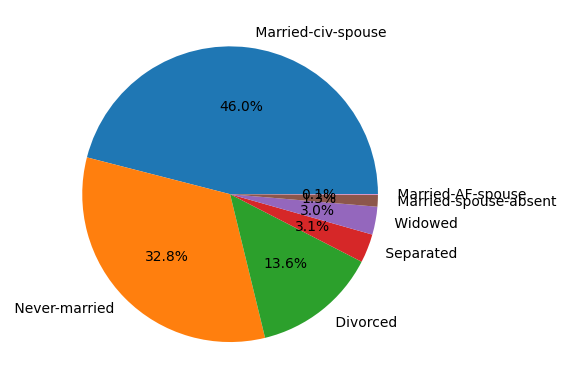

In [5]:
marital_status_abs.plot.pie(autopct="%.1f%%")
plt.ylabel(None)
plt.show()

# Creating a Bar Graph :

We can display the same datas using another kind of graph

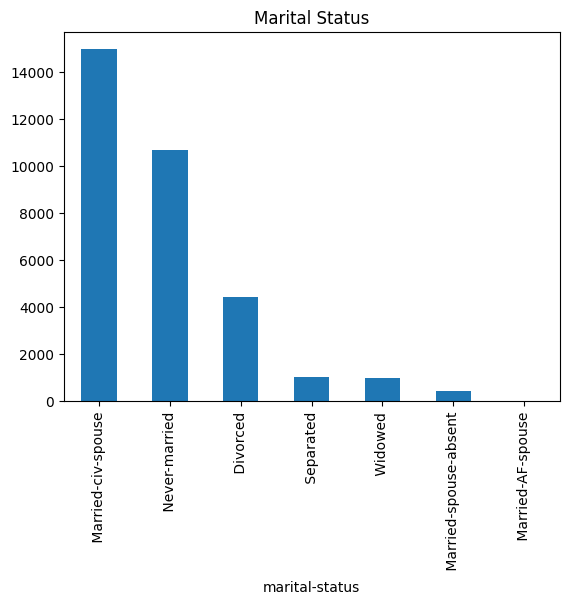

In [6]:
marital_status_abs.plot.bar(title = "Marital Status")
plt.show()

# Box Layout :

From thiskind of graph we can see  where most of values are placed and find eventual outlayers.

<Axes: xlabel='age'>

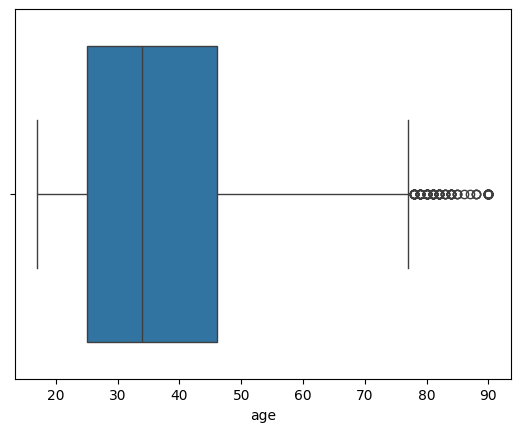

In [7]:
ages = df['age'][df['income'] == " <=50K"]
sns.boxplot(x=ages)



# 📊 Simple Arithmetic Average (Mean) :

The **Arithmetic Mean** — often just called the **average** — is the sum of all values in a dataset divided by the number of values.  
It is the most common measure of **central tendency**, representing a "typical" value.

🔹 When to Use
- Works for **numerical** data.
- Useful when you want a single number summarizing the dataset.
- Best when data is **symmetrically distributed** without extreme outliers.

In [8]:
average_age = df["age"].mean()
print("Average_age :" , round(average_age))

Average_age : 39


# 📊 The Median :

The **Median** is the value that lies exactly in the middle of an **ordered dataset**.  
It splits the data into two equal halves:
- 50% of the values are **less than or equal** to the median.
- 50% of the values are **greater than or equal** to the median.

🔹 When to Use :
- Works for **numerical** and **ordinal** data.
- Useful when the dataset contains **outliers** or is **skewed**, because it is less affected by extreme values than the mean.
- Common in reporting incomes, property prices, and other skewed distributions.

🔹 How to Find the Median :
1. Arrange the data in **ascending order**.
2. If the number of observations (**n**) is **odd**:
   - Median = the middle value.
3. If **n** is **even**:
   - Median = the average of the two middle values.


In [9]:
median_age = df["age"].median()
print("Average_age :" , round(median_age))


Average_age : 37


# 📊 Understanding the Mode :

The **Mode** is the value that appears **most frequently** in a dataset.  
It is one of the three main measures of **central tendency**, alongside the **mean** and **median**.

🔹 When to Use
- Works for **numerical** and **categorical** data.
- Useful for identifying the **most common** value or category.
- Especially relevant when the most frequent observation is more meaningful than the average.

🔹 Key Points :
- A dataset can have:
  - **No mode** (all values occur equally often)
  - **One mode** → *unimodal*
  - **Two modes** → *bimodal*
  - **More than two modes** → *multimodal*
- The mode is **not affected** by extreme values (outliers).

In [10]:
most_common_age = sts.mode(df["age"])
print("Most Common Age : ", most_common_age)

Most Common Age :  36


# 📊 Range (Max − Min) :

The **Range** is the simplest measure of variability in a dataset.  
It is calculated as the **difference between the maximum and minimum values**.

- Gives a quick sense of the **spread** of the data.
- Easy to compute and understand.
- Useful for a **first look** at variability before using more complex measures.


🔹 Limitations :
- **Sensitive to outliers** — a single extreme value can greatly increase the range.
- Does not show how values are distributed between the min and max.




In [11]:
max_age , min_age = max(df["age"]), min(df["age"])
print("Max Age : ", max_age , "\nMin age : ", min_age , "\nVariation index : ", max_age-min_age)

Max Age :  90 
Min age :  17 
Variation index :  73


# 📊 Variance :

**Variance** is a statistical measure that describes how far the values in a dataset are spread out from the mean.  
It quantifies the **average squared deviation** of each data point from the mean.

🔹 Why It Matters

- Shows the **degree of dispersion** in the data.
- A **small variance** means values are close to the mean → low variability.
- A **large variance** means values are spread out → high variability.
- Used in statistics, finance, science, and quality control to assess consistency and risk.

In [12]:
variance = np.var(df["age"], ddof = 1)
print("Variance : ", round(variance))

Variance :  186


# 📊 Standard Deviation :

The **standard deviation (SD)** is a measure of how spread out the values in a dataset are.  
It tells us, on average, how far each value lies from the **mean** (average) of the dataset.
Standard deviation is the square of the variance


🔹 Why It Matters
- A **low** standard deviation means the data points are close to the mean → less variability.
- A **high** standard deviation means the data points are spread out over a wider range → more variability.
- It’s widely used in statistics, finance, science, and quality control to understand **consistency** and **risk**.




In [13]:
standard_dev = np.std(df["age"], ddof =1)
print("Standard Deviation : ", standard_dev)

Standard Deviation :  13.640432553581341


# 📊 Coefficient of Variation (CV) :

The Coefficient of Variation (CV) is a statistical measure of relative variability.
It is defined as the ratio of the standard deviation to the mean, often expressed as a percentage.
Formula:
     CV = (Standard Deviation / Mean) * 100

 ✅ Why use it?
 - Compares variability between datasets with different units or scales
 - Useful in finance, quality control, and scientific research

📌 Interpretation:
- Lower CV → more consistency, datas are less scattered
- Higher CV → more variability relative to the mean

In [ ]:
Variation_Coeff = standard_dev / average_age

print("Variation Cohefficent : ", round(Variation_Coeff*100), " %")


Variation Cohefficent :  35
